In [1]:
import pandas as pd
# colnames=['video_id', 'middle_frame_timestamp', 'x1', 'x2', 'y1', 'y2', 'action_id', 'person_id'] 
# kinetics_train = pd.read_csv('/data1/hongn/ava_kinetics_v1_0/kinetics_train_v1.0.csv', names=colnames, header=None)

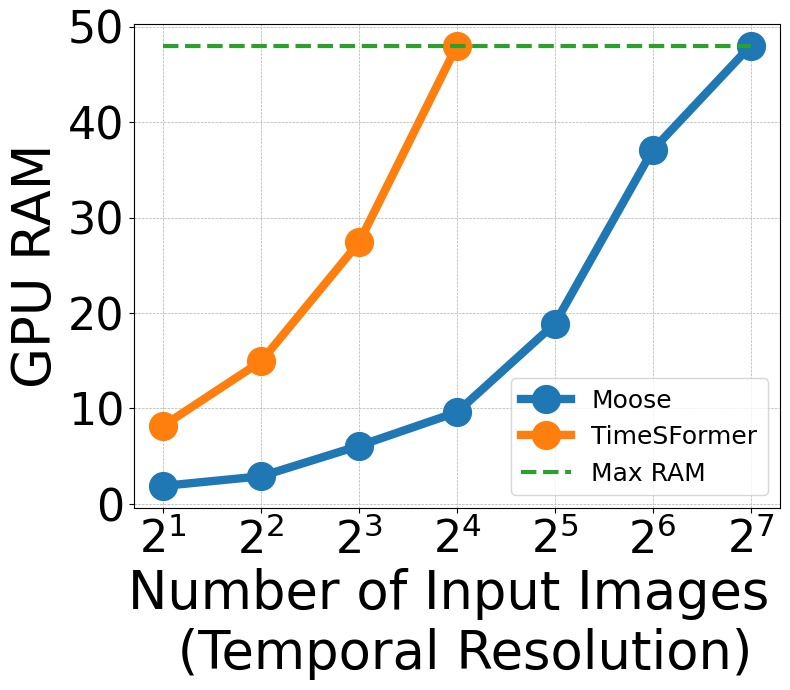

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
x = np.array([2, 4, 8, 16, 32, 64, 128])  # Powers of 2
y1 = np.array([1.89, 2.90, 6.09, 9.61, 18.89, 37.09, 48])  # Example full line
y2 = np.array([8.19, 14.94, 27.40, 48, np.nan, np.nan, np.nan])  # Cut-off line
y3 = np.ones(len(x))*48
# Cut off y2 after index 5
y2_cut = y2.copy()
# y2_cut[6:] = np.nan

# Plotting
plt.figure(figsize=(8, 7))
plt.plot(x, y1, label='Moose', linewidth=6, marker='o', markersize=20)
plt.plot(x, y2_cut, label='TimeSFormer', linewidth=6, marker='o', markersize=20)
plt.plot(x, y3, label='Max RAM', linestyle='--', linewidth=3)
plt.xticks(fontsize=32)
plt.yticks(fontsize=32)
plt.xscale('log', base=2)
plt.xlabel("Number of Input Images \n (Temporal Resolution)", fontsize=38)
plt.ylabel("GPU RAM", fontsize=38)
# plt.title("Line Plot with Log2 X-Axis and Cut-Off Line")
plt.legend(loc=4, prop={'size': 18})
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


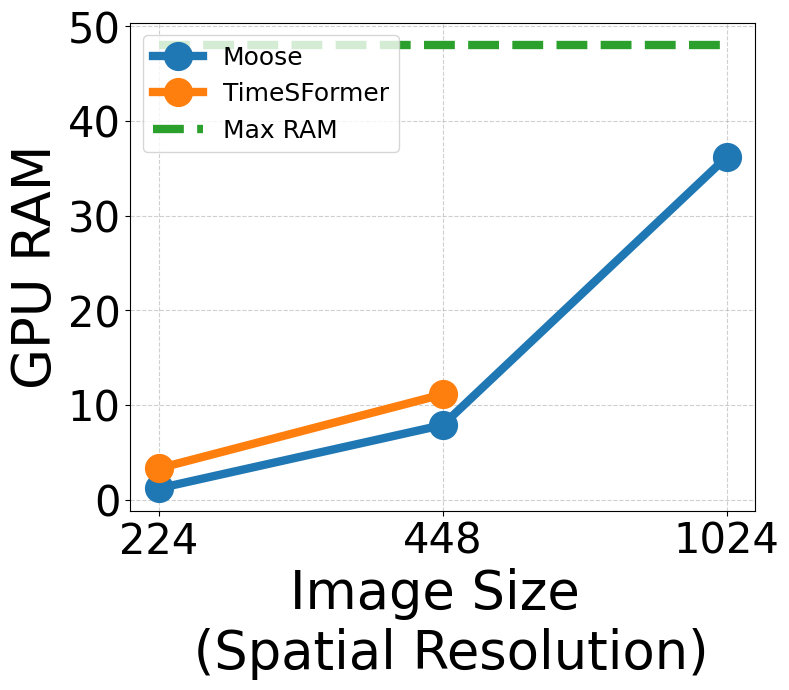

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Categorical x-axis labels
x_labels = ['224', '448', '1024']

# Example y-values
# y1 = np.linspace(0, 1, len(x_labels))              # Full line
# y2 = np.linspace(0.5, 0.9, len(x_labels))          # Cut-off line
y1 = np.array([1.20, 7.89, 36.20])  # Example full line
y2 = np.array([3.31, 11.13, np.nan])  # Cut-off line
y3 = np.ones(len(x_labels))*48
# Simulate cut-off by replacing part of y2 with NaN
y2_cut = y2.copy()
y2_cut[3:] = np.nan

# Plotting
plt.figure(figsize=(8, 7))
plt.plot(x_labels, y1, label='Moose', marker='o', linewidth=6, markersize=20)
plt.plot(x_labels, y2_cut, label='TimeSFormer', marker='o', linewidth=6, markersize=20)
plt.plot(x_labels, y3, label='Max RAM', linestyle='--', linewidth=6)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel("Image Size \n (Spatial Resolution)", fontsize=38)
plt.ylabel("GPU RAM", fontsize=38)
# plt.title("Line Plot with Categorical X-Axis and Cut-Off Line")
plt.legend(loc=2, prop={'size': 18})
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## AVA

In [1]:
import pandas as pd
colnames=['video_id', 'middle_frame_timestamp', 'x1', 'x2', 'y1', 'y2', 'action_id', 'person_id'] 
val_ava = pd.read_csv('/data1/hongn/ava_kinetics_v1_0/ava_val_v2.2.csv', names=colnames, header=None).dropna()
val_ava.head()

ModuleNotFoundError: No module named 'pandas'

In [1]:
from timesformer.datasets.ava import Ava
# from timesformer.datasets.kinetics import Kinetics
from timesformer.utils.parser import load_config
import torch

import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--cfg_file', help="restore checkpoint")
parser.add_argument('--opts', help="restore checkpoint")
args = parser.parse_args(['--cfg_file', "/data2/hongn/TimePSFormer/configs/Kinetics/Moose_divST_8x32_224.yaml"]) 
cfg = load_config(args)

dataset = Ava(cfg, "train")
# kinetic = Kinetics(cfg, "train")

/data2/hongn/miniconda3/envs/moose/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
imgs, label_arrs, idx, _, extra_data = dataset[0]

In [2]:
cfg.TRAIN.BATCH_SIZE

2

In [3]:
from timesformer.datasets import utils as utils
split = "train"
from torch.utils.data._utils.collate import default_collate
import itertools
import numpy as np

def multiple_samples_collate(batch, fold=False):
    """
    Collate function for repeated augmentation. Each instance in the batch has
    more than one sample.
    Args:
        batch (tuple or list): data batch to collate.
    Returns:
        (tuple): collated data batch.
    """
    inputs, labels, video_idx, time, extra_data = zip(*batch)
    inputs = [item for sublist in inputs for item in sublist]
    labels = [item for sublist in labels for item in sublist]
    video_idx = [item for sublist in video_idx for item in sublist]
    time = [item for sublist in time for item in sublist]

    inputs, labels, video_idx, time, extra_data = (
        default_collate(inputs),
        default_collate(labels),
        default_collate(video_idx),
        default_collate(time),
        default_collate(extra_data),
    )
    if fold:
        return [inputs], labels, video_idx, time, extra_data
    else:
        return inputs, labels, video_idx, time, extra_data


def detection_collate(batch):
    """
    Collate function for detection task. Concatanate bboxes, labels and
    metadata from different samples in the first dimension instead of
    stacking them to have a batch-size dimension.
    Args:
        batch (tuple or list): data batch to collate.
    Returns:
        (tuple): collated detection data batch.
    """
    inputs, labels, video_idx, time, extra_data = zip(*batch)
    inputs, video_idx = default_collate(inputs), default_collate(video_idx)
    time = default_collate(time)
    labels = torch.tensor(np.concatenate(labels, axis=0)).float()

    collated_extra_data = {}
    for key in extra_data[0].keys():
        data = [d[key] for d in extra_data]
        if key == "boxes" or key == "ori_boxes":
            # Append idx info to the bboxes before concatenating them.
            bboxes = [
                np.concatenate(
                    [np.full((data[i].shape[0], 1), float(i)), data[i]], axis=1
                )
                for i in range(len(data))
            ]
            bboxes = np.concatenate(bboxes, axis=0)
            collated_extra_data[key] = torch.tensor(bboxes).float()
        elif key == "metadata":
            collated_extra_data[key] = torch.tensor(list(itertools.chain(*data))).view(
                -1, 2
            )
        else:
            collated_extra_data[key] = default_collate(data)

    return inputs, labels, video_idx, time, collated_extra_data

assert split in ["train", "val", "test"]
if split in ["train"]:
    dataset_name = cfg.TRAIN.DATASET
    batch_size = int(cfg.TRAIN.BATCH_SIZE / max(1, cfg.NUM_GPUS))
    shuffle = True
    drop_last = True
elif split in ["val"]:
    dataset_name = cfg.TRAIN.DATASET
    batch_size = int(cfg.TRAIN.BATCH_SIZE / max(1, cfg.NUM_GPUS))
    shuffle = False
    drop_last = False
elif split in ["test"]:
    dataset_name = cfg.TEST.DATASET
    batch_size = int(cfg.TEST.BATCH_SIZE / max(1, cfg.NUM_GPUS))
    shuffle = False
    drop_last = False
    
loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(False if None else shuffle),
            sampler=None,
            num_workers=cfg.DATA_LOADER.NUM_WORKERS,
            pin_memory=cfg.DATA_LOADER.PIN_MEMORY,
            drop_last=drop_last,
            collate_fn=detection_collate,
            worker_init_fn=utils.loader_worker_init_fn(dataset),
        )

In [4]:
for cur_iter, (inputs, labels, _, _) in enumerate(loader):
    break

KeyboardInterrupt: 

In [12]:
imgs, label_arrs, idx, _, extra_data = next(iter(loader))

In [16]:
len(label_arrs)

4

In [26]:
import torch
isinstance(kinetic, torch.utils.data.IterableDataset)

False

In [21]:
extra_data['boxes'].shape

(6, 4)

In [22]:
label_arrs.shape

(6, 400)

In [17]:
imgs[0].shape

torch.Size([3, 9, 224, 224])

In [12]:
imgs[1].shape

IndexError: list index out of range

## SSv2 Everything

In [20]:
import glob
import os
ssv2_dir = glob.glob('/data1/hongn/SSv2/frames/*')
list_empty_folder = []
for path in ssv2_dir:
    if len(os.listdir(path)) == 0:
        list_empty_folder.append(path)

In [ ]:
['/data1/hongn/SSv2/frames/123178', '/data1/hongn/SSv2/frames/123156']
list_empty_folder

['/data1/hongn/SSv2/frames/123178', '/data1/hongn/SSv2/frames/123156']

In [66]:
#TimeSFormer AVA lavel, turn out, it does not need to be processed
import pandas as pd
val = pd.read_csv('/data1/hongn/SSv2/labels/val.csv')
col_merge = 'original_vido_id video_id frame_id path labels'
val[col_merge.split(' ')] = val[col_merge].str.split(' ', expand=True)
val = val.drop(col_merge, axis=1)
# val.to_csv('/data1/hongn/SSv2/labels/train.csv', index=False, header=True)
# val.head()

In [67]:
from tqdm import tqdm

list_empty_folder = []

for name in tqdm(val.path):
    if(os.path.isfile('/data1/hongn/SSv2/frames/' + name) == False):
        list_empty_folder.append(name)

100%|██████████| 3018451/3018451 [01:19<00:00, 37919.14it/s] 


In [ ]:
list_empty_folder

In [68]:
folder_redo = [name.split('/')[0] for name in list_empty_folder]
set(folder_redo)

set()

## HAA500

In [1]:
import pandas as pd
train = pd.read_csv('/data1/hongn/kinetics-dataset/k400/train.csv')
train.head()

,/data1/hongn/kinetics-dataset/k400/train/8mbN0ubh0q8_000000_000010.mp4,101
0,/data1/hongn/kinetics-dataset/k400/train/9bfc-...,17
1,/data1/hongn/kinetics-dataset/k400/train/VV0KA...,167
2,/data1/hongn/kinetics-dataset/k400/train/sWCnx...,318
3,/data1/hongn/kinetics-dataset/k400/train/Am6c9...,356
4,/data1/hongn/kinetics-dataset/k400/train/pC1hX...,231


In [3]:
train_haa500 = pd.read_csv('/data1/hongn/haa500/raw/climb_icecliff.txt')
train_haa500.head()

,https://www.youtube.com/watch?v=Uo_sDYOvW98,113.19,116.11,1,1.1
0,https://www.youtube.com/watch?v=79s5BD0301o,348.50,351.50,1,1
1,https://www.youtube.com/watch?v=1syox_mjE6s,124.41,127.13,0,1
2,https://www.youtube.com/watch?v=OnV0XbwSAAM,423.48,426.39,0,2
3,https://www.youtube.com/watch?v=Xp83UFuKxyE,616.31,619.07,1,1
4,https://www.youtube.com/watch?v=-iDBPhSc2mU,130.50,133.15,0,1


In [123]:
from glob import glob
import numpy as np

action_folders = glob('/mnt/d/haa500/video/*')
label_nameidx_map = pd.DataFrame(columns=['label_name', 'label_index'])
# all_data = pd.DataFrame(columns=['paths', 'labels'])
# actions
action_paths = []
labels = []
for i in range(len(action_folders)):
    action_name = action_folders[i].split('/')[-1]
    # print(action_name)
    label_nameidx_map.loc[i] = [action_name, i]
    actioni_paths = glob(f'/mnt/d/haa500/video/{action_name}/*')
    action_paths.append(actioni_paths)
    labels.append(np.ones(len(actioni_paths)) * i)

action_paths = np.array(action_paths).flatten()
labels = np.array(labels).flatten().astype(int)

In [124]:
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(action_paths, labels, test_size=0.33, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.33, random_state=42, shuffle=True)

In [125]:
train = pd.DataFrame(np.stack([X_train, y_train], axis=1), columns=['paths', 'labels'])
val = pd.DataFrame(np.stack([X_val, y_val], axis=1), columns=['paths', 'labels'])
test = pd.DataFrame(np.stack([X_test, y_test], axis=1), columns=['paths', 'labels'])

label_nameidx_map.to_csv('/mnt/d/haa500/label_nameidx_map.csv',index=False, header=False)
train.to_csv('/mnt/d/haa500/train.csv',index=False, header=False)
val.to_csv('/mnt/d/haa500/val.csv',index=False, header=False)
test.to_csv('/mnt/d/haa500/test.csv',index=False, header=False)

In [8]:
np.stack([X_train, y_train], axis=1)

array([['/mnt/d/haa500/video/decorating_snowman/decorating_snowman_001.mp4',
        '121'],
       ['/mnt/d/haa500/video/play_noseflute/play_noseflute_014.mp4',
        '297'],
       ['/mnt/d/haa500/video/fire_dancing_circulating/fire_dancing_circulating_019.mp4',
        '159'],
       ...,
       ['/mnt/d/haa500/video/figure_skate_jump_spin/figure_skate_jump_spin_017.mp4',
        '155'],
       ['/mnt/d/haa500/video/soccer_throw/soccer_throw_006.mp4', '395'],
       ['/mnt/d/haa500/video/tennis_backhand/tennis_backhand_003.mp4',
        '432']], dtype='<U103')

In [88]:
y_train

array([121, 297, 159, ..., 155, 395, 432])

In [81]:
labels.astype(int)

array([  0,   0,   0, ..., 499, 499, 499])

In [69]:
import numpy as np
actioni = glob('/data1/hongn/haa500/video/gym_plank/*')
len(actioni)
np.ones(len(actioni)) * i

array([499., 499., 499., 499., 499., 499., 499., 499., 499., 499., 499.,
       499., 499., 499., 499., 499., 499., 499., 499., 499.])

In [68]:
all_data = pd.DataFrame(columns=['paths', 'labels'])
temp = np.stack([actioni, np.ones(len(actioni))], axis=1)
all_data = pd.concat([all_data,pd.Series(temp)], ignore_index=True)
all_data

ValueError: Data must be 1-dimensional, got ndarray of shape (20, 2) instead

In [7]:
actions[12]

'/data1/hongn/haa500/raw/play_ukulele.txt'

## rtMRI Phonemes

In [119]:
from glob import glob
import numpy as np

action_folders = glob('/mnt/d/phone_clips/video/*')
label_nameidx_map = pd.DataFrame(columns=['label_name', 'label_index'])
# all_data = pd.DataFrame(columns=['paths', 'labels'])
# actions
action_paths = []
labels = []
for i in range(len(action_folders)):
    action_name = action_folders[i].split('/')[-1]
    # print(action_name)
    label_nameidx_map.loc[i] = [action_name, i]
    actioni_paths = glob(f'/mnt/d/phone_clips/video/{action_name}/*')
    action_paths.append(actioni_paths)
    labels.append(np.ones(len(actioni_paths)) * i)

action_paths = np.concatenate(np.array(action_paths, dtype=object))
labels = np.concatenate(np.array(list(labels), dtype=object)).astype(int)

In [120]:
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(action_paths, labels, test_size=0.33, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.33, random_state=42, shuffle=True)

In [122]:
train = pd.DataFrame(np.stack([X_train, y_train], axis=1), columns=['paths', 'labels'])
val = pd.DataFrame(np.stack([X_val, y_val], axis=1), columns=['paths', 'labels'])
test = pd.DataFrame(np.stack([X_test, y_test], axis=1), columns=['paths', 'labels'])

label_nameidx_map.to_csv('/mnt/d/phone_clips/label_nameidx_map.csv',index=False, header=False)
train.to_csv('/mnt/d/phone_clips/train.csv',index=False, header=False)
val.to_csv('/mnt/d/phone_clips/val.csv',index=False, header=False)
test.to_csv('/mnt/d/phone_clips/test.csv',index=False, header=False)

## UCF 101

In [126]:
from glob import glob
import numpy as np

action_folders = glob('/mnt/d/UCF101/video/*')
label_nameidx_map = pd.DataFrame(columns=['label_name', 'label_index'])
# all_data = pd.DataFrame(columns=['paths', 'labels'])
# actions
action_paths = []
labels = []
for i in range(len(action_folders)):
    action_name = action_folders[i].split('/')[-1]
    # print(action_name)
    label_nameidx_map.loc[i] = [action_name, i]
    actioni_paths = glob(f'/mnt/d/UCF101/video/{action_name}/*')
    action_paths.append(actioni_paths)
    labels.append(np.ones(len(actioni_paths)) * i)

action_paths = np.concatenate(np.array(action_paths, dtype=object))
labels = np.concatenate(np.array(list(labels), dtype=object)).astype(int)

In [127]:
from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(action_paths, labels, test_size=0.33, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.33, random_state=42, shuffle=True)

In [128]:
train = pd.DataFrame(np.stack([X_train, y_train], axis=1), columns=['paths', 'labels'])
val = pd.DataFrame(np.stack([X_val, y_val], axis=1), columns=['paths', 'labels'])
test = pd.DataFrame(np.stack([X_test, y_test], axis=1), columns=['paths', 'labels'])

label_nameidx_map.to_csv('/mnt/d/UCF101/label_nameidx_map.csv',index=False, header=False)
train.to_csv('/mnt/d/UCF101/train.csv',index=False, header=False)
val.to_csv('/mnt/d/UCF101/val.csv',index=False, header=False)
test.to_csv('/mnt/d/UCF101/test.csv',index=False, header=False)

## Vacation

In [43]:
import pandas as pd

def load_annotation_txt(filepath, delimiter=' '):
    # Define expected column names
    column_names = [
        'bbx ID', 'xmin', 'ymin', 'xmax', 'ymax',
        'frame ID', 'lost', 'occluded', 'generated',
        'bbx label', 'event attribute', 'atomic attribute', 'attention focus'
    ]
    
    # Load the file into a DataFrame
    df = pd.read_csv(
        filepath,
        delimiter=delimiter,
        header=None,
        names=column_names,
        na_values=['', 'NA', 'NaN', None]
    )
    
    return df

# Example usage:
# df = load_annotation_txt("annotations.txt", delimiter='\t')  # or ',' or ' ' depending on your file
# print(df.head())


In [50]:
import pandas as pd
videoi = load_annotation_txt('/mnt/d/VACATION-dataset/annotations/NewAnt_7.txt')
filtered_vid = videoi[videoi['bbx label'].str.contains(r'^Person[1]$', na=False)]
filtered_vid

,bbx ID,xmin,ymin,xmax,ymax,frame ID,lost,occluded,generated,bbx label,event attribute,atomic attribute,attention focus
1,0,123,151,177,219,0,0,0,0,Person1,JointAtt,share,O1
4,0,122,150,176,218,1,0,0,1,Person1,JointAtt,share,O1
7,0,122,150,176,218,2,0,0,1,Person1,JointAtt,share,O1
10,0,122,149,176,217,3,0,0,1,Person1,JointAtt,share,O1
13,0,121,149,175,217,4,0,0,1,Person1,JointAtt,share,O1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,9,155,36,214,101,307,0,0,1,Person1,JointAtt,follow,O1
821,9,156,36,213,100,308,0,0,1,Person1,JointAtt,follow,O1
824,9,157,36,212,99,309,0,0,1,Person1,JointAtt,follow,O1
827,9,158,36,211,99,310,0,0,1,Person1,JointAtt,follow,O1


In [70]:
# df = load_annotation_txt('annotations.txt', delimiter=',')
extract_all_frames('/mnt/d/VACATION-dataset/video/7.mp4', '/mnt/d/VACATION-dataset/temp', fps=25)
group_and_copy_frames_by_attribute(filtered_vid, '/mnt/d/VACATION-dataset/temp', '/mnt/d/VACATION-dataset/clips_processed', fps=25)
encode_segments_to_video('/mnt/d/VACATION-dataset/grouped_frames', '/mnt/d/VACATION-dataset/video_segments', fps=25)

Extracting all frames at 25 FPS...


ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 13.3.0 (conda-forge gcc 13.3.0-1)
  configuration: --prefix=/home/hongn/miniconda3/envs/slowfast --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enable-l

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/d/VACATION-dataset/grouped_frames'

In [67]:
extract_clips_by_atomic_attribute(filtered_vid, '/mnt/d/VACATION-dataset/video/7.mp4', '/mnt/d/VACATION-dataset/clips_processed')

Extracting clip 0: share, frames 0-9
Extracting clip 1: single, frames 10-41
Extracting clip 2: follow, frames 42-48
Extracting clip 3: share, frames 103-155
Extracting clip 4: single, frames 156-160
Extracting clip 5: single, frames 203-219
Extracting clip 6: follow, frames 220-311


ffmpeg version 7.1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 13.3.0 (conda-forge gcc 13.3.0-1)
  configuration: --prefix=/home/hongn/miniconda3/envs/slowfast --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1732155191655/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libmp3lame --enable-libvpx --enable-libass --enable-pthreads --enable-vaapi --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enable-l

In [69]:
import os
import pandas as pd
import shutil

def extract_all_frames(video_path, output_frames_dir, fps=25, image_format='png'):
    os.makedirs(output_frames_dir, exist_ok=True)

    cmd = [
        'ffmpeg',
        '-i', video_path,
        '-vf', f'fps={fps}',
        os.path.join(output_frames_dir, f'frame_%05d.{image_format}')
    ]

    print("Extracting all frames at 25 FPS...")
    os.system(' '.join(cmd))

def group_and_copy_frames_by_attribute(df, input_frames_dir, output_dir, fps=25, image_format='png'):
    os.makedirs(output_dir, exist_ok=True)

    df = df[df['atomic attribute'].notna()]
    df = df[['frame ID', 'atomic attribute']].drop_duplicates().sort_values('frame ID')

    # Group by contiguous atomic attribute
    segments = []
    current_group = []
    prev_attr = None
    prev_frame = -2

    for _, row in df.iterrows():
        curr_frame = row['frame ID']
        curr_attr = row['atomic attribute']

        if curr_attr == prev_attr and curr_frame == prev_frame + 1:
            current_group.append(curr_frame)
        else:
            if current_group:
                segments.append((prev_attr, current_group))
            current_group = [curr_frame]

        prev_attr = curr_attr
        prev_frame = curr_frame

    if current_group:
        segments.append((prev_attr, current_group))

    # Copy frames into separate folders
    for i, (attr, frames) in enumerate(segments):
        segment_dir = os.path.join(output_dir, f"{i}_{attr.replace(' ', '_')}")
        os.makedirs(segment_dir, exist_ok=True)

        for j, frame_id in enumerate(frames):
            input_file = os.path.join(input_frames_dir, f"frame_{frame_id + 1:05d}.{image_format}")
            output_file = os.path.join(segment_dir, f"frame_{j:05d}.{image_format}")
            if os.path.exists(input_file):
                shutil.copy(input_file, output_file)
            else:
                print(f"Missing frame: {input_file}")

def encode_segments_to_video(output_dir, output_video_dir, fps=25, image_format='png'):
    os.makedirs(output_video_dir, exist_ok=True)
    for segment in os.listdir(output_dir):
        segment_path = os.path.join(output_dir, segment)
        if os.path.isdir(segment_path):
            output_file = os.path.join(output_video_dir, f"{segment}.mp4")
            cmd = [
                'ffmpeg',
                '-y',
                '-framerate', str(fps),
                '-i', os.path.join(segment_path, f'frame_%05d.{image_format}'),
                '-c:v', 'libx264',
                '-pix_fmt', 'yuv420p',
                output_file
            ]
            print(f"Encoding: {output_file}")
            os.system(' '.join(cmd))

# Example usage:
# df = load_annotation_txt('annotations.txt', delimiter=',')
# extract_all_frames('input_video.mp4', 'all_frames', fps=25)
# group_and_copy_frames_by_attribute(df, 'all_frames', 'grouped_frames', fps=25)
# encode_segments_to_video('grouped_frames', 'video_segments', fps=25)
